In [21]:
import numpy as np
import matplotlib.pyplot as plt

# LSN Exercises 06
## Ising model 

Gabriele Borroni (14768A)

---
## The Ising model

The Ising model consists of a discrete lattice filled with **spins**, modelled as variables which can only take binary values ${\pm 1}$. It was originally developed to study the magnetism of materials, but it has since found widespread use in a variety of interdisciplinary applications.

The key idea is that the total energy of the system depends on the **alignment of the spins**, and thus it changes every time a spin is flipped, according to a mechanism where each spin is influenced by its **nearest neighbours**.

The Hamiltonian of a 1D Ising model is given by:
$$
\mathcal{H} = -J \sum_{\langle i,j \rangle} s_i s_j - h \sum_i s_i
$$

Where J is the **ferromagnetic interaction constant**, which governs the interaction between neighbouring spins: 
if $s_is_j=+1$ the energy lowers, and the system favours parallel states to minimize energy.

h parametrizes the magnitude of an **external field**:
- h>0 : the energy lowers if spin is pointing up, and so these states are favoured.
- h<0 : the energy lowers if spin is pointing down, and so these states are favoured.
- h=0 : only the spin interaction acts on the system's energy.

In statistical physics, the Ising model can be described as a canonical ensemble, a system with fixed (N,V,T). the most powerful tool to study this kind of systems is the **partition function Z**, a sum over the energies associated to all possible microscopic configurations, each weighted by its **Boltzmann factor** $e^{-\beta E_i}$, where $\beta=\frac{1}{k_BT}$.
$$
Z=\sum_i e^{-\beta E_i}
$$

This quantity contains all the statistical information about the system, and it can be used to compute any thermodynamic quantity. For example, the probability of finding the system in a state with energy $E^*$ is given by:
$$
P(E^*)=\frac{e^{-\beta E^*}}{Z}
$$
so that the partition function acts as a **normalization constant** for the probability distribution of the system's energy.

However, computing Z for the Ising model is possible only in the 1D and 2D cases, and for the first case it is given by:

$$
Z=\sum_{\{ s_i \}} e^{ -\beta H} = \lambda_1^N + \lambda_2^N
$$
Where
$$\lambda_{1,2} = 
e^{\beta J} 
\cosh (\beta h) \pm \left[ e^{2\beta J} \cosh^2 (\beta h) - 2\sinh (2\beta J) \right]^{1/2}$$

Once the partition function has been computed, the Helmholtz free energy is readily obtained as $A = -k_B T \ln Z$. All the thermodynamic quantities of interest can be deduced from $A$ or, equivalently, from $Z$:

- the **Internal Energy** per spin (with $h=0$):

$$
\frac{U(N,T)}{N} =  -J \tanh (\beta J) \Biggl( \frac{1 + \tanh^{N-2} (\beta J)}{1+\tanh^N (\beta J)} \Biggl)
$$

- the **Heat Capacity** (with $h=0$):

$$
\frac{C(N,T)}{N} = \frac{1}{N}\frac{\partial U(N,T)}{\partial T} =\\
\underset{h=0}= 
k_B (\beta J)^2 \left\{ 1+\tanh^N (\beta J)+(N-1)\tanh^2 (\beta J)+(N-1)\frac{\tanh^{N-2} (\beta J)}{1+\tanh^N (\beta J)}
- N \left[ \frac{\tanh (\beta J) + \tanh^{N-1} (\beta J)}{1+\tanh^N (\beta J)} \right]^2 \right\}
$$

- The **magnetization** (with $h \not= 0$):


$$
\frac{M(N,T,h)}{N}=\frac{e^{\beta J}\; \sinh(\beta h)}{Z} \; \Bigl[\lambda_1^{N-1}\cdot \Bigl(1+\frac{e^{\beta J}\; \cosh(\beta h)}{\sqrt{e^{2\beta J} \cosh^2 (\beta h) - 2\sinh (2\beta J)}}\Bigr) + \lambda_2^{N-1}\cdot \Bigl(1-\frac{e^{\beta J}\; \cosh(\beta h)}{\sqrt{e^{2\beta J} \cosh^2 (\beta h) - 2\sinh (2\beta J)}}\Bigr)\Bigr]
$$

(with h=0, also M=0 for symmetry: no external field breaks the up/down degeneracy)
- The **magnetic susceptibility** (with $h=0$):

$$
\chi(N,T) = \beta e^{2\beta J} \Biggl( \frac{1-\tanh^N (\beta J)}{1+\tanh^N (\beta J)} \Biggl)
$$

The enhanced code from the previous lecture has been used to compute these quantities. To simulate each configuration, two different sampling algorithms have been implemented: 

- The Metropolis algorithm:

1. choose a random site on the lattice


2. propose a move (spin flip) and evaluate the difference in energy that doing so would bring: $\Delta E= E_{proposed}-E_0$


3. accept the new configuration with probability $P=\min{1, e^{-\beta \Delta E}}$ if $ E_{proposed} >E_0$, or accept automatically if $ E_{proposed}< E_0$.


It's possible to show that, after an equilibration period, the Metropolis algorithm will sample configurations according to the canonical Boltzmann distribution P(E).


- The Gibbs sampling algorithm:


1. Choose a random site on the lattice


2. Compute the conditional probability that the spin is up $s_i=+1$:
$P(s_i = +1) = \frac{1}{1 + e^{-2\beta h_i}}$

        
3. Draw a random number $ r \in [0,1] $, and set: 
        $$s_i =\begin{cases}+1 & \text{if } r < P(s_i = +1) \\-1 & \text{otherwise}
\end{cases}$$
Unlike Metropolis, the Gibbs algorithm avoids rejection by directly sampling from the local conditional probability. It can be seen as a "Metropolis with acceptance=1".
This leads to faster convergence in systems where conditional probabilities are tractable.

Results of the calculations of specific heat, total energy, magnetization and susceptibility obtained by data blocking are shown below, with comparison to the analytical solutions.
Statistical estimators make possible to compute the mentioned quantities as:
1. $U(N,T) = \langle H \rangle_{h=0}$
2. $C(N,T) = k_B \beta^2 (\langle H^2 \rangle_{h=0}-\langle H \rangle_{h=0}^2)$ 
3. $\chi(N,T) = \beta \langle (\sum_{i=1,N}s_i)^2 \rangle_{h=0}$
4. $M(N,T,h=0.02)= \langle \sum_{i=1,N}s_i \rangle_{h=0.02}$



In [22]:
J = 1.0
Ns = 50
def Teo_Energy(T):
   beta = 1/T
   th = np.tanh(J/T)
   thN= th**Ns
   ch = 1/th
   return -J*( th + ch*thN )/( 1 + thN )

def Teo_chi(T):
   beta = 1/T
   th = np.tanh(J/T)
   thN= th**Ns
   ch = 1/th
   return beta*np.exp(2*beta*J)*(1-thN)/(1+thN)

def Teo_Mag(T):
   h=0.02 #external field
   b = 1/T

   l1 = np.exp(b*J)*np.cosh(b*h)+np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))
   l2 = np.exp(b*J)*np.cosh(b*h)-np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))
   Z = l1**Ns + l2**Ns
   return (np.exp(b*J)*np.sinh(b*h)*((l1**(Ns-1))*(1+np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))) 
        + (l2**(Ns-1))*(1-np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J)))))/(Z)

def Teo_Cv(T):
   beta = 1/T
   th = np.tanh(J/T)
   thN= th**Ns
   ch = 1/th
   return ((beta*J)**2)*(((1+thN+(Ns-1)*(th**2)+(Ns-1)*(ch**2)*thN)/(1+thN))-Ns*((th+ch*thN)/(1+thN))**2)


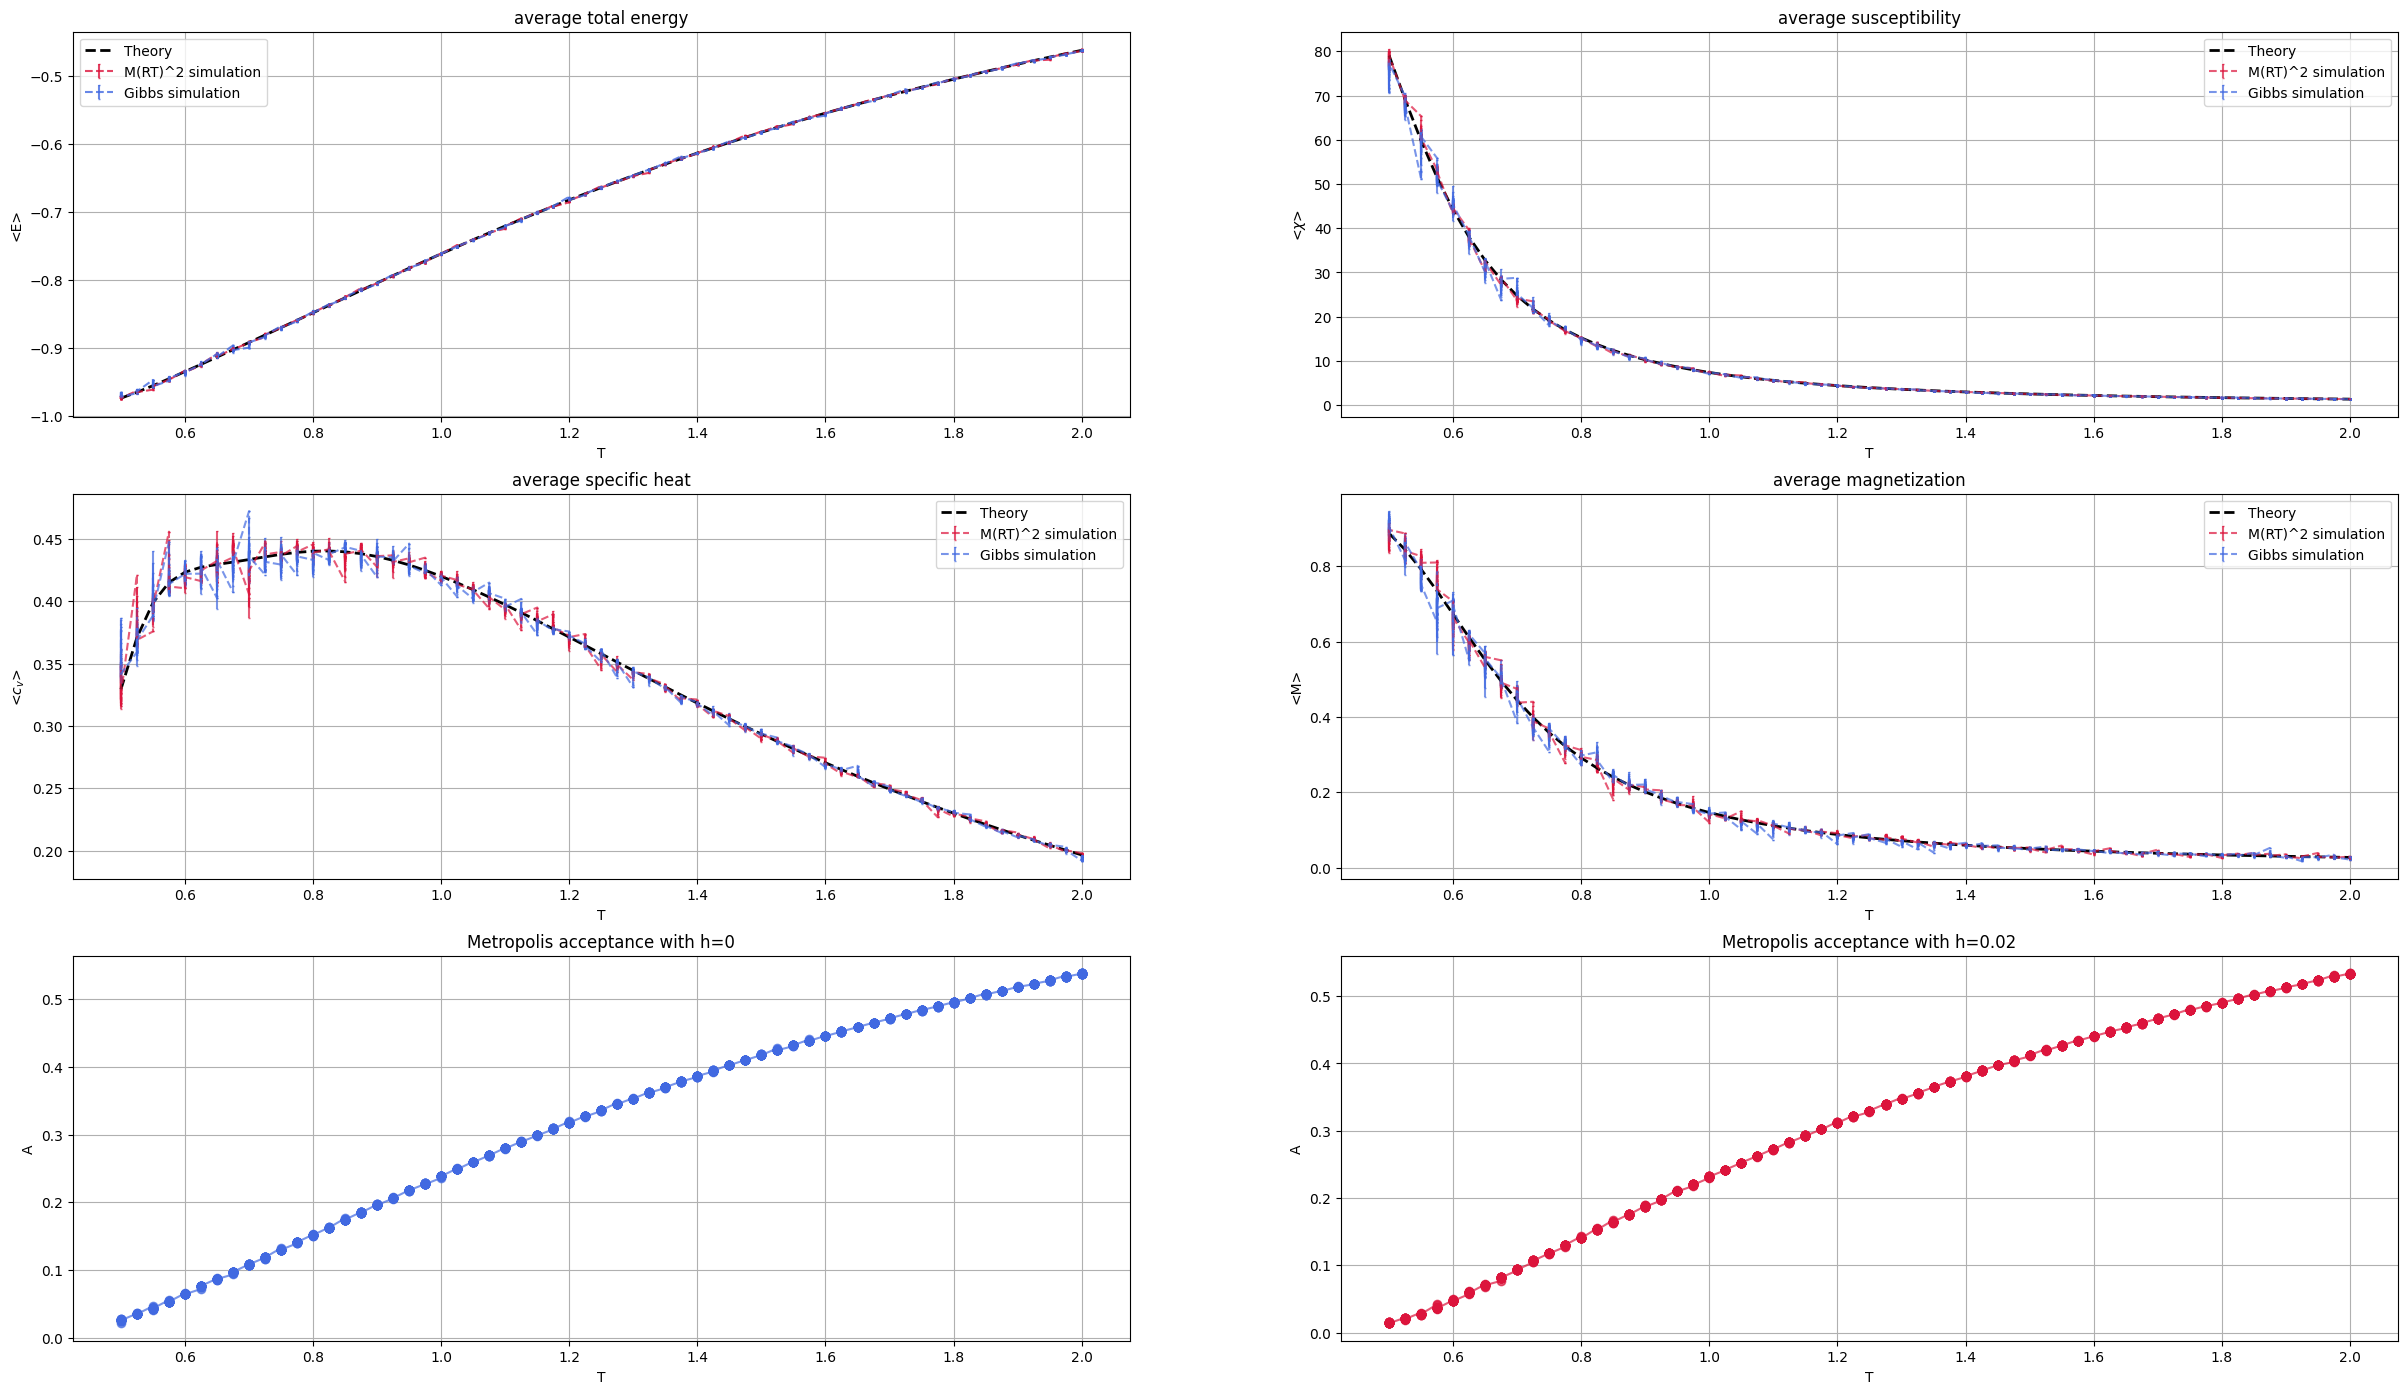

In [23]:

#load data
energiesM=np.loadtxt("6.1/NSL_SIMULATOR/OUTPUT/total_energyM.dat")
susceptibilityM=np.loadtxt("6.1/NSL_SIMULATOR/OUTPUT/susceptibilityM.dat")
specific_heatM=np.loadtxt("6.1/NSL_SIMULATOR/OUTPUT/specific_heatM.dat")
magnetizationM=np.loadtxt("6.1/NSL_SIMULATOR/OUTPUT/magnetizationM.dat")
energiesG=np.loadtxt("6.1/NSL_SIMULATOR/OUTPUT/total_energyG.dat")
susceptibilityG=np.loadtxt("6.1/NSL_SIMULATOR/OUTPUT/susceptibilityG.dat")
specific_heatG=np.loadtxt("6.1/NSL_SIMULATOR/OUTPUT/specific_heatG.dat")
magnetizationG=np.loadtxt("6.1/NSL_SIMULATOR/OUTPUT/magnetizationG.dat")
A00=np.loadtxt("6.1/NSL_SIMULATOR/OUTPUT/acceptance00.dat")
A02=np.loadtxt("6.1/NSL_SIMULATOR/OUTPUT/acceptance02.dat")
T=energiesM[:,0]
EM=energiesM[:,3]
err_EM=energiesM[:,4]
chiM=susceptibilityM[:,3]
err_chiM=susceptibilityM[:,4]
cvM=specific_heatM[:,3]
err_cvM=specific_heatM[:,4]
MM=magnetizationM[:,3]
err_MM=magnetizationM[:,4]
EG=energiesG[:,3]
err_EG=energiesG[:,4]
chiG=susceptibilityG[:,3]
err_chiG=susceptibilityG[:,4]
cvG=specific_heatG[:,3]
err_cvG=specific_heatG[:,4]
MG=magnetizationG[:,3]
err_MG=magnetizationG[:,4]
A0=A00[:,1]
A02=A02[:,1]
n=A00[:,0]
N=np.arange(len(n))

def plot_chi(ax, T, chi, err, color, label, teo=False):
    ax.errorbar(T,chi, yerr=err, capsize=0.5,alpha=0.7, fmt='--',color=color,label=label)
    ax.set_xlabel("T")
    ax.set_ylabel(r"<$\chi$>")
    ax.set_title("average susceptibility")
    ax.grid(True)
    if teo:
        Chi_teo=Teo_chi(T)
        ax.plot(T,Chi_teo, color="black",ls='--', lw=2, label="Theory")
    ax.legend()
def plot_E(ax, T,E,err, color, label, teo=False):
    ax.errorbar(T,E, yerr=err,capsize=0.5,alpha=0.8, color=color,fmt= '--',label=label)
    ax.set_xlabel("T")
    ax.set_ylabel("<E>")
    ax.set_title("average total energy")
    ax.grid(True)
    if teo:
        E_teo=Teo_Energy(T)
        ax.plot(T,E_teo, color="black",ls='--', lw=2, label="Theory")
    ax.legend()
def plot_cv(ax, T, cv, err, color, label, teo=False):
    ax.errorbar(T,cv, yerr=err,capsize=0.5,alpha=0.7, fmt='--',color=color,label=label)
    ax.set_xlabel("T")
    ax.set_ylabel(r"<$c_v$>")
    ax.set_title("average specific heat")
    ax.grid(True)
    if teo:
        Cv_teo=Teo_Cv(T)
        ax.plot(T,Cv_teo, color="black",ls='--', lw=2, label="Theory")
    ax.legend()
def plot_M(ax, T, M, err, color, label, teo=False):
    ax.errorbar(T,M, yerr=err,capsize=0.5,alpha=0.7, fmt='--',color=color,label=label)
    ax.set_xlabel("T")
    ax.set_ylabel("<M>")
    ax.set_title("average magnetization")
    ax.grid(True)
    if teo:
        Cv_teo=Teo_Mag(T)
        ax.plot(T,Cv_teo, color="black",ls='--', lw=2, label="Theory")
    ax.legend()
def plot_A(ax, n, a, color, h):
    ax.plot(n,a, '-o', color=color, alpha=0.7)
    ax.grid(True)
    ax.set_xlabel("T")
    ax.set_ylabel("A")
    ax.set_title(f"Metropolis acceptance with h={h}")

#plot
fig, ax=plt.subplots(3,2, figsize=(30,17))
ax=ax.flatten()

plot_E(ax[0],T, EM, err_EM,"crimson", "M(RT)^2 simulation", True)
plot_E(ax[0],T, EG, err_EG,"royalblue", "Gibbs simulation")
plot_chi(ax[1],T, chiM, err_chiM,"crimson", "M(RT)^2 simulation", True)
plot_chi(ax[1],T, chiG, err_chiG,"royalblue", "Gibbs simulation")
plot_cv(ax[2],T, cvM, err_cvM, "crimson", "M(RT)^2 simulation", True)
plot_cv(ax[2],T, cvG, err_cvG,"royalblue", "Gibbs simulation")
plot_M(ax[3],T, MM, err_MM, "crimson", "M(RT)^2 simulation", True)
plot_M(ax[3],T, MG, err_MG,"royalblue", "Gibbs simulation")
plot_A(ax[4], T, A0, "Royalblue", 0)
plot_A(ax[5], T, A02, "crimson", 0.02)

plt.show()